# 🌍 Realism in Climate Change: An Alternative to Alarmism and Denial
### A 20-minute hands-on session for university instructors

---

**How this notebook works:** Run each cell in order (`Shift+Enter`). Every section maps to one part of the session plan. Add your own notes in the 📝 reflection cells — they won't affect the code.

| Section | Topic | ILO |
|---------|-------|-----|
| 0 | Setup — install & import everything | — |
| 1 | Radiative-Convective Equilibrium (RCE) | ILO 1 |
| 2 | Clausius–Clapeyron: temperature → moisture | ILO 2 |
| 3 | Storm environment simulation (CAPE) | ILO 3 |
| 4 | Role-play prompts | ILO 4 |

---
## Section 0 — Setup
Run this cell first. It installs any missing packages and imports everything the notebook needs.

In [1]:
# ── Install (safe to re-run; skips if already present) ──────────────────────
import importlib, subprocess, sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
from scipy.constants import sigma   # Stefan-Boltzmann constant

def ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

ensure('numpy')
ensure('matplotlib')
ensure('scipy')
ensure('metpy')       # atmospheric thermodynamics & skew-T plots
ensure('pint')        # unit handling used by metpy

# ── Core imports ────────────────────────────────────────────────────────────


import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('✅  All packages loaded successfully.')

Matplotlib is building the font cache; this may take a moment.


✅  All packages loaded successfully.


---
## Section 1 — Radiative-Convective Equilibrium (RCE)
### ILO 1: *Explain why increased CO₂ raises equilibrium temperature using the RCE model*

**The core idea in one sentence:** The atmosphere is partially opaque to outgoing infrared radiation. CO₂ raises that opacity, so the planet must warm up until it can radiate enough energy to balance incoming sunlight.

We model this with a **single-layer grey atmosphere**:

$$T_s = T_{\text{eff}} \cdot \left(\frac{2}{2 - \varepsilon}\right)^{1/4}$$

where:
- $T_{\text{eff}} = \left(\frac{S_0(1-\alpha)}{4\sigma}\right)^{1/4}$ is the effective emission temperature (~255 K for Earth)
- $\varepsilon$ is the **emissivity** of the atmosphere (0 = fully transparent, 1 = fully opaque)
- CO₂ increases $\varepsilon$, which directly raises $T_s$

This is the simplest possible model that captures the greenhouse effect — no fluid dynamics, no clouds, but the physics is real.

Effective emission temperature (no atmosphere): 254.6 K  (-18.6 °C)


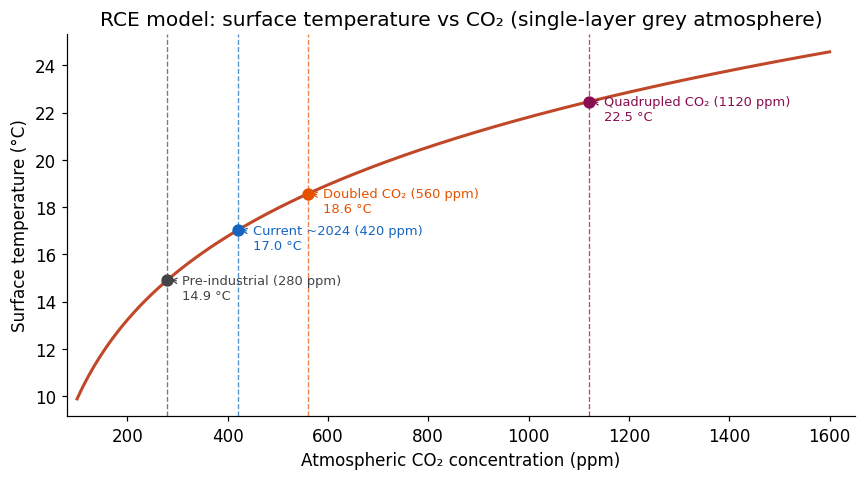


🌡️  Warming from doubling CO₂ (280→560 ppm): +3.65 K
   (Real-world estimate from complex GCMs: ~3 K — our simple model gets the sign and order right!)


In [2]:
# ── RCE: single-layer grey atmosphere ───────────────────────────────────────

# Physical constants
S0    = 1361.0    # Solar constant (W/m²)
alpha = 0.30      # Earth's Bond albedo
sigma_SB = sigma  # Stefan-Boltzmann (W/m²/K⁴)

# Effective emission temperature (no atmosphere)
T_eff = (S0 * (1 - alpha) / (4 * sigma_SB)) ** 0.25
print(f'Effective emission temperature (no atmosphere): {T_eff:.1f} K  ({T_eff-273.15:.1f} °C)')

def surface_temp(epsilon):
    """Surface temperature for a single-layer grey atmosphere."""
    return T_eff * (2 / (2 - epsilon)) ** 0.25

# ── Baseline vs doubled-CO₂ scenario ────────────────────────────────────────
# We map CO₂ concentration to emissivity using a log relationship
# (Beer–Lambert: absorption ~ log(concentration))
CO2_ref  = 280.0   # pre-industrial CO₂ (ppm)
eps_ref  = 0.78    # calibrated to give ~288 K baseline surface temperature

def epsilon_from_co2(co2_ppm):
    """Map CO₂ concentration to atmospheric emissivity (log scaling)."""
    return eps_ref + 0.06 * np.log2(co2_ppm / CO2_ref)

co2_values = np.linspace(100, 1600, 400)
T_surface  = [surface_temp(epsilon_from_co2(c)) for c in co2_values]

# Key scenarios
scenarios = {
    'Pre-industrial (280 ppm)':  280,
    'Current ~2024 (420 ppm)':   420,
    'Doubled CO₂ (560 ppm)':     560,
    'Quadrupled CO₂ (1120 ppm)': 1120,
}

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(co2_values, [t - 273.15 for t in T_surface], color='#C04828', lw=2)

colors = ['#444444', '#1565C0', '#E65100', '#880E4F']
for (label, co2), color in zip(scenarios.items(), colors):
    T = surface_temp(epsilon_from_co2(co2)) - 273.15
    ax.axvline(co2, color=color, linestyle='--', lw=0.9, alpha=0.7)
    ax.scatter([co2], [T], color=color, zorder=5, s=50)
    ax.annotate(f'{label}\n{T:.1f} °C', xy=(co2, T),
                xytext=(co2 + 30, T - 0.8), fontsize=8.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

ax.set_xlabel('Atmospheric CO₂ concentration (ppm)')
ax.set_ylabel('Surface temperature (°C)')
ax.set_title('RCE model: surface temperature vs CO₂ (single-layer grey atmosphere)')
ax.set_xlim(80, 1650)
plt.tight_layout()
plt.show()

# Warming from doubling CO₂
dT_2x = (surface_temp(epsilon_from_co2(560)) - surface_temp(epsilon_from_co2(280)))
print(f'\n🌡️  Warming from doubling CO₂ (280→560 ppm): +{dT_2x:.2f} K')
print(f'   (Real-world estimate from complex GCMs: ~3 K — our simple model gets the sign and order right!)')

### 📝 ILO 1 — Your annotation

> **In one or two sentences: why does doubling CO₂ raise surface temperature?**  
> *(Write your answer here before moving on.)*

*Your answer:*

---

---
## Section 2 — Clausius–Clapeyron: Temperature → Atmospheric Moisture
### ILO 2: *Relate increased T to greater moisture capacity and explain the link to more intense storms*

A warmer atmosphere can hold more water vapour. The relationship is given by the **Clausius–Clapeyron equation**:

$$\frac{de_s}{dT} = \frac{L_v \, e_s}{R_v \, T^2}$$

which integrates to:

$$e_s(T) = e_{s,0} \exp\!\left[\frac{L_v}{R_v}\left(\frac{1}{T_0} - \frac{1}{T}\right)\right]$$

The key result: **saturation vapour pressure increases by ~7% per °C of warming.**

More water vapour = more latent heat released when air rises and condenses = more energy available for storms.

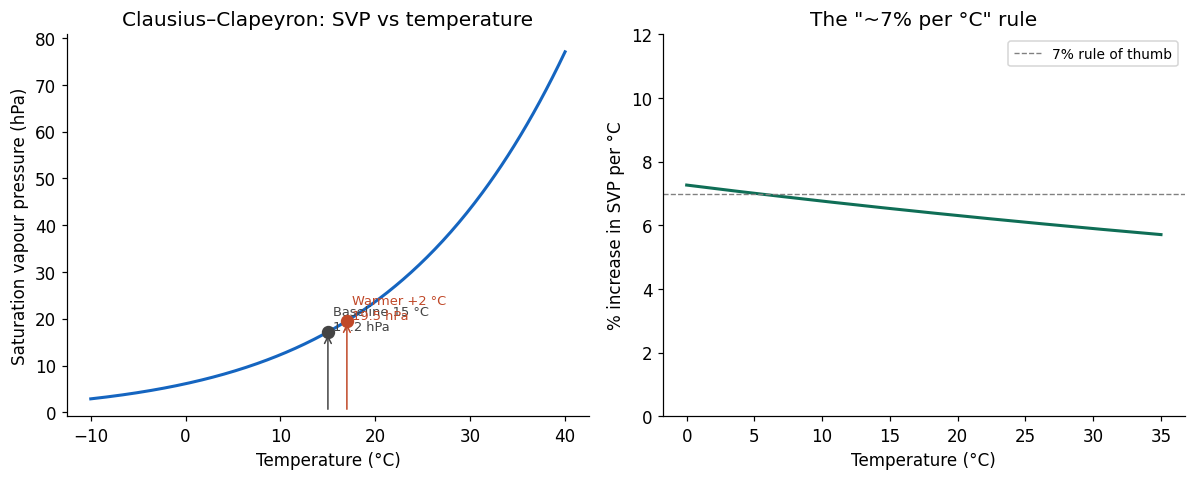

At 15.0°C baseline, a 2.0°C warming increases SVP by 13.8%
This means ~13.8% more water vapour available to fuel storms.


In [3]:
# ── Clausius–Clapeyron: saturation vapour pressure ──────────────────────────

Lv  = 2.501e6   # Latent heat of vaporisation (J/kg)
Rv  = 461.5     # Gas constant for water vapour (J/kg/K)
T0  = 273.15    # Reference temperature (K)
es0 = 611.2     # Saturation vapour pressure at 0°C (Pa)

def sat_vapour_pressure(T_celsius):
    """Saturation vapour pressure (Pa) via Clausius-Clapeyron."""
    T_K = T_celsius + 273.15
    return es0 * np.exp((Lv / Rv) * (1/T0 - 1/T_K))

T_range = np.linspace(-10, 40, 300)
es      = sat_vapour_pressure(T_range)

# ── Plot SVP curve ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: SVP vs temperature
ax = axes[0]
ax.plot(T_range, es / 100, color='#1565C0', lw=2)  # convert Pa to hPa

# Highlight two scenarios: baseline 15°C and +2°C
for T_base, color, label in [(15, '#444444', 'Baseline 15 °C'),
                              (17, '#C04828', 'Warmer +2 °C')]:
    es_val = sat_vapour_pressure(T_base)
    ax.annotate('', xy=(T_base, es_val/100), xytext=(T_base, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1))
    ax.scatter([T_base], [es_val/100], color=color, zorder=5, s=60)
    ax.text(T_base + 0.5, es_val/100 + 0.3, f'{label}\n{es_val/100:.1f} hPa',
            fontsize=8.5, color=color)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Saturation vapour pressure (hPa)')
ax.set_title('Clausius–Clapeyron: SVP vs temperature')

# Right: % increase in SVP per degree (should be ~7%/°C)
ax2 = axes[1]
T_mid = np.linspace(0, 35, 200)
dT    = 0.01
pct_increase = 100 * (sat_vapour_pressure(T_mid + dT) - sat_vapour_pressure(T_mid)) \
               / sat_vapour_pressure(T_mid) / dT

ax2.plot(T_mid, pct_increase, color='#0F6E56', lw=2)
ax2.axhline(7, color='gray', linestyle='--', lw=0.9, label='7% rule of thumb')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('% increase in SVP per °C')
ax2.set_title('The "~7% per °C" rule')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 12)

plt.tight_layout()
plt.show()

# ── One-line calculation ─────────────────────────────────────────────────────
T_baseline = 15.0   # °C — typical warm-season surface temperature
dT_warming = 2.0    # °C — end-of-century mid-range warming

es_base = sat_vapour_pressure(T_baseline)
es_warm = sat_vapour_pressure(T_baseline + dT_warming)
pct_more = 100 * (es_warm - es_base) / es_base

print(f'At {T_baseline}°C baseline, a {dT_warming}°C warming increases SVP by {pct_more:.1f}%')
print(f'This means ~{pct_more:.1f}% more water vapour available to fuel storms.')

### 📝 ILO 2 — Your annotation

> **In your own words: why does a warmer atmosphere produce more intense storms?**  
> *(Hint: connect SVP → latent heat → CAPE. Write your answer here.)*

*Your answer:*

---

---
## Section 3 — Severe Convective Storm (SCS) Environment
### ILO 3: *Run a storm-environment simulation; predict and interpret the CAPE change*

**CAPE** (Convective Available Potential Energy, J/kg) measures how much energy a rising air parcel can extract from its environment. It is the single best predictor of storm intensity:

| CAPE (J/kg) | Interpretation |
|-------------|----------------|
| < 300 | Weak convection |
| 300–1000 | Moderate |
| 1000–2500 | Large — severe storms possible |
| > 2500 | Extreme — supercell/tornado environment |

$$\text{CAPE} = g \int_{LFC}^{EL} \frac{T_{\text{parcel}} - T_{\text{env}}}{T_{\text{env}}} \, dz$$

We construct an **idealised sounding** (vertical profile of temperature and humidity), then compute CAPE using MetPy's thermodynamics library.

**Before running:** predict — will CAPE increase or decrease in the warmer scenario, and by roughly what percentage?

In [4]:
# ── 🔮 YOUR PREDICTION (fill this in before running the next cell) ────────────

my_prediction = """
I predict CAPE will [increase / decrease] by approximately [  ]%
because ...
"""

print(my_prediction)


I predict CAPE will [increase / decrease] by approximately [  ]%
because ...



In [5]:
# ── Idealised sounding builder ───────────────────────────────────────────────

def build_sounding(T_surface_C=28.0, dT_warming=0.0, dewpoint_depression=6.0):
    """
    Construct an idealised severe convective storm sounding.

    Parameters
    ----------
    T_surface_C        : Surface temperature (°C)
    dT_warming         : Additional warming applied to the surface layer (°C)
    dewpoint_depression: T - Td at surface (°C); smaller = moister boundary layer

    Returns
    -------
    pressure, temperature, dewpoint  (all MetPy Quantity arrays)
    """
    # Pressure levels (hPa) — surface to tropopause
    p_levels = np.array([1000, 975, 950, 925, 900, 875, 850, 825, 800,
                          775, 750, 700, 650, 600, 550, 500, 450, 400,
                          350, 300, 250, 200]) * units.hPa

    T_sfc = T_surface_C + dT_warming

    # Environmental lapse rate: ~6.5 K/km in the troposphere
    # Approximate altitude via hypsometric: z ~ 8.5 km * ln(1000/p)
    z_approx = 8500 * np.log(1000 / p_levels.magnitude)  # metres

    # Temperature profile: surface + ELR, with tropopause cap
    lapse_rate = 6.5e-3   # K/m (environmental lapse rate)
    T_profile  = T_sfc - lapse_rate * z_approx
    T_tropo    = -56.5    # tropopause temperature (°C)
    T_profile  = np.maximum(T_profile, T_tropo)

    # Increase surface moisture with warming (Clausius-Clapeyron: ~7%/°C)
    # Dewpoint depression stays roughly constant → dewpoint rises with T
    Td_sfc = T_sfc - dewpoint_depression

    # Dewpoint decreases with altitude (simplified: 1.8 K/km above 850 hPa)
    Td_profile = np.where(
        z_approx < 1500,
        Td_sfc - 1.8e-3 * z_approx,           # moist BL
        Td_sfc - 1.8e-3 * 1500 - 4e-3 * (z_approx - 1500)  # drier free trop
    )
    # Dewpoint can't exceed temperature
    Td_profile = np.minimum(Td_profile, T_profile - 0.1)

    return (p_levels,
            T_profile  * units.degC,
            Td_profile * units.degC)


def compute_cape(p, T, Td):
    """Compute CAPE and CIN using MetPy's parcel method."""
    parcel_prof = mpcalc.parcel_profile(p, T[0], Td[0]).to(units.degC)
    cape, cin   = mpcalc.cape_cin(p, T, Td, parcel_prof)
    return cape.magnitude, cin.magnitude, parcel_prof


# ── Run two scenarios ────────────────────────────────────────────────────────
p_ctrl, T_ctrl, Td_ctrl = build_sounding(T_surface_C=28.0, dT_warming=0.0)
p_warm, T_warm, Td_warm = build_sounding(T_surface_C=28.0, dT_warming=2.0)

cape_ctrl, cin_ctrl, prof_ctrl = compute_cape(p_ctrl, T_ctrl, Td_ctrl)
cape_warm, cin_warm, prof_warm = compute_cape(p_warm, T_warm, Td_warm)

pct_change = 100 * (cape_warm - cape_ctrl) / cape_ctrl

print('─' * 50)
print(f'  Control (+0 °C):  CAPE = {cape_ctrl:6.0f} J/kg   CIN = {cin_ctrl:.0f} J/kg')
print(f'  Warmer  (+2 °C):  CAPE = {cape_warm:6.0f} J/kg   CIN = {cin_warm:.0f} J/kg')
print(f'  Change:           CAPE  {pct_change:+.1f}%')
print('─' * 50)

──────────────────────────────────────────────────
  Control (+0 °C):  CAPE =   3140 J/kg   CIN = -85 J/kg
  Warmer  (+2 °C):  CAPE =   3975 J/kg   CIN = -85 J/kg
  Change:           CAPE  +26.6%
──────────────────────────────────────────────────


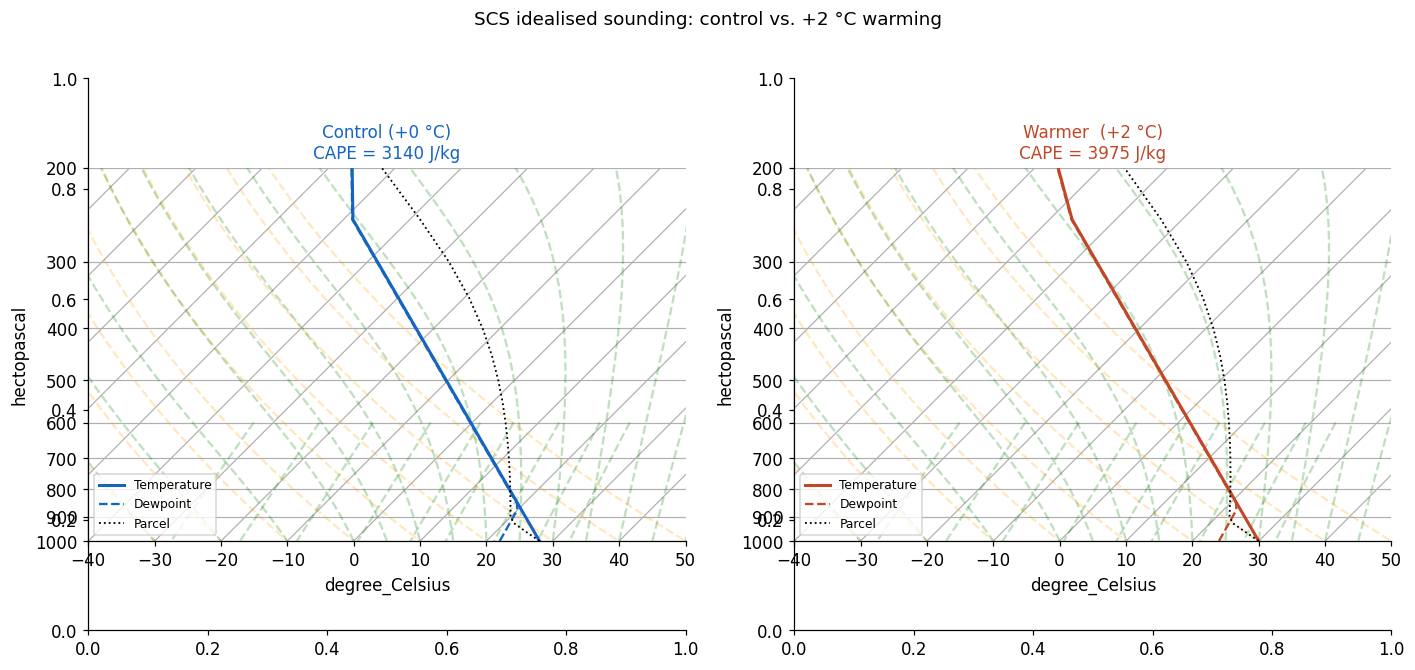

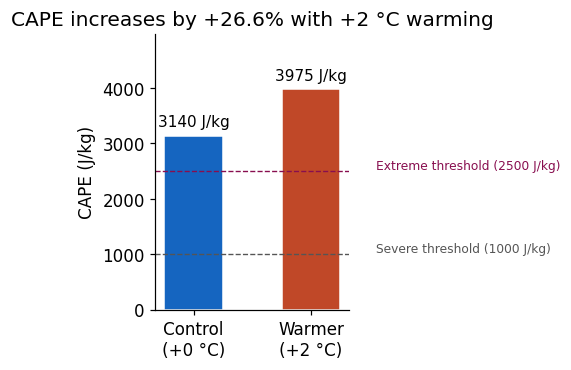


📊 Record your result: CAPE increased by 26.6%
   Compare with your prediction in the cell above!


In [6]:
# ── Skew-T Log-P plots ───────────────────────────────────────────────────────

fig = plt.figure(figsize=(13, 6))

for idx, (p, T, Td, prof, cape, label, color) in enumerate([
    (p_ctrl, T_ctrl, Td_ctrl, prof_ctrl, cape_ctrl, 'Control (+0 °C)', '#1565C0'),
    (p_warm, T_warm, Td_warm, prof_warm, cape_warm, 'Warmer  (+2 °C)', '#C04828'),
]):
    ax = fig.add_subplot(1, 2, idx+1, projection='skewx')
    skew = SkewT(fig, rotation=45, subplot=(1, 2, idx+1))

    skew.plot(p, T,  color, linewidth=2, label='Temperature')
    skew.plot(p, Td, color, linewidth=1.5, linestyle='--', label='Dewpoint')
    skew.plot(p, prof, 'k', linewidth=1.2, linestyle=':', label='Parcel')

    skew.plot_dry_adiabats(alpha=0.25, colors='orange')
    skew.plot_moist_adiabats(alpha=0.25, colors='green')
    skew.plot_mixing_lines(alpha=0.25)

    skew.ax.set_ylim(1000, 200)
    skew.ax.set_xlim(-40, 50)
    skew.ax.set_title(f'{label}\nCAPE = {cape:.0f} J/kg', fontsize=11, color=color)
    skew.ax.legend(fontsize=8, loc='lower left')

plt.suptitle('SCS idealised sounding: control vs. +2 °C warming', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Bar chart of CAPE comparison ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 3.5))
bars = ax2.bar(['Control\n(+0 °C)', 'Warmer\n(+2 °C)'],
               [cape_ctrl, cape_warm],
               color=['#1565C0', '#C04828'], width=0.5, edgecolor='white')
ax2.bar_label(bars, fmt='%.0f J/kg', padding=4, fontsize=10)
ax2.set_ylabel('CAPE (J/kg)')
ax2.set_title(f'CAPE increases by {pct_change:+.1f}% with +2 °C warming')
ax2.set_ylim(0, max(cape_ctrl, cape_warm) * 1.25)

# Reference lines
for val, label, color in [(1000, 'Severe threshold (1000 J/kg)', '#555555'),
                           (2500, 'Extreme threshold (2500 J/kg)', '#880E4F')]:
    ax2.axhline(val, linestyle='--', linewidth=0.9, color=color)
    ax2.text(1.55, val + 30, label, fontsize=8, color=color)

plt.tight_layout()
plt.show()

print(f'\n📊 Record your result: CAPE increased by {pct_change:.1f}%')
print(   '   Compare with your prediction in the cell above!')

### 📝 ILO 3 — Your annotation

> **By what % did CAPE increase? Did it match your prediction? What physical mechanism drove the change?**

*Your answer:*

---

---
## Section 4 — Role-Play: Grounding a Peer
### ILO 4: *Apply the physical causal chain to ground a peer in evidence-based reasoning*

**No code in this section.** You've just built a physical causal chain:

> CO₂ ↑ → emissivity ↑ → surface T ↑ → SVP ↑ → atmospheric moisture ↑ → CAPE ↑ → more intense storms

Now you'll use it in a conversation.

---

### Scenario A — The Doomer

> *"We're all going to die. The models say 4 degrees by 2100, the Amazon is collapsing, every scientist says we're past the tipping point — there's literally no point doing anything."*

**Your task:** Without dismissing the real concern, ground this person in what the physics actually says — and what it does *not* say.

*(Use what you computed: what does a 2°C warming actually do to storms? Is that the end of the world, or a serious but quantifiable risk?)*

---

### Scenario B — The Denier

> *"CO₂ is literally plant food. It's 0.04% of the atmosphere — a trace gas. This whole thing is political. Climate has always changed naturally."*

**Your task:** Using the RCE model result, explain *specifically* why even a small change in emissivity has a large effect on surface temperature. What physical evidence would you point to?

---

### 📝 Reflection

> **Which physical argument did you find most effective? Which concept from the notebook did your partner find most compelling?**

*Your notes from the role-play:*

---

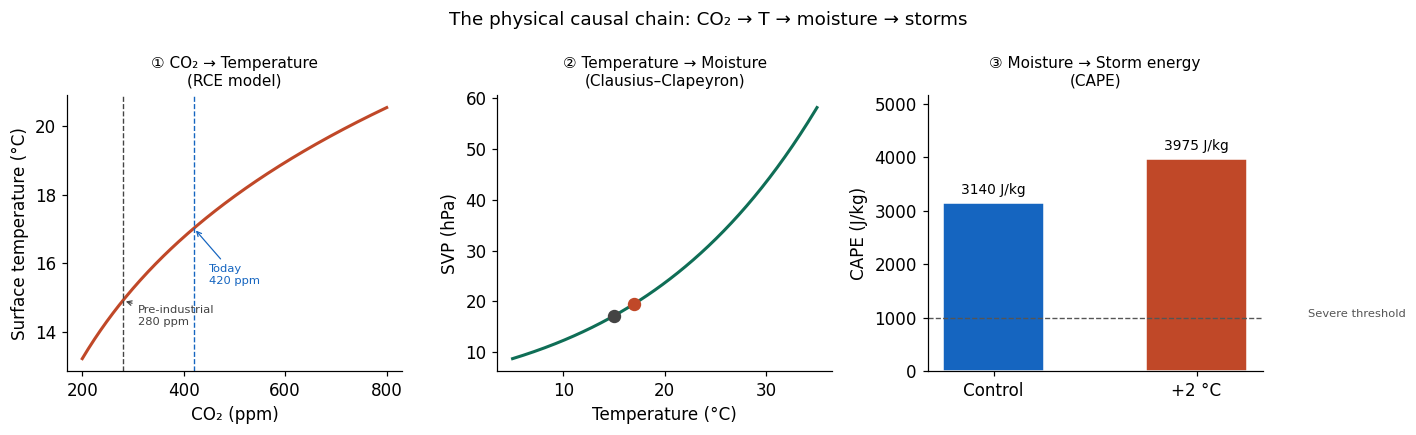


✅  Session complete. Use the three panels above during your role-play.


In [7]:
# ── Visual summary: the causal chain ─────────────────────────────────────────
# Run this cell to produce a clean summary figure you can refer to during the role-play

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: CO₂ → T (from RCE section)
co2_v = np.linspace(200, 800, 200)
T_v   = [surface_temp(epsilon_from_co2(c)) - 273.15 for c in co2_v]
axes[0].plot(co2_v, T_v, '#C04828', lw=2)
axes[0].axvline(280, color='#444', linestyle='--', lw=0.9)
axes[0].axvline(420, color='#1565C0', linestyle='--', lw=0.9)
axes[0].set_xlabel('CO₂ (ppm)')
axes[0].set_ylabel('Surface temperature (°C)')
axes[0].set_title('① CO₂ → Temperature\n(RCE model)', fontsize=10)
axes[0].annotate('Pre-industrial\n280 ppm', xy=(280, surface_temp(epsilon_from_co2(280))-273.15),
                 xytext=(310, 14.2), fontsize=7.5, color='#444',
                 arrowprops=dict(arrowstyle='->', color='#444', lw=0.8))
axes[0].annotate('Today\n420 ppm', xy=(420, surface_temp(epsilon_from_co2(420))-273.15),
                 xytext=(450, 15.4), fontsize=7.5, color='#1565C0',
                 arrowprops=dict(arrowstyle='->', color='#1565C0', lw=0.8))

# Panel 2: T → SVP (from C-C section)
T_range2 = np.linspace(5, 35, 200)
es2      = sat_vapour_pressure(T_range2)
axes[1].plot(T_range2, es2/100, '#0F6E56', lw=2)
for T_pt, color in [(15, '#444'), (17, '#C04828')]:
    axes[1].scatter([T_pt], [sat_vapour_pressure(T_pt)/100], color=color, zorder=5, s=60)
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('SVP (hPa)')
axes[1].set_title('② Temperature → Moisture\n(Clausius–Clapeyron)', fontsize=10)

# Panel 3: Moisture → CAPE bar chart
bars = axes[2].bar(['Control', '+2 °C'], [cape_ctrl, cape_warm],
                   color=['#1565C0', '#C04828'], width=0.5, edgecolor='white')
axes[2].bar_label(bars, fmt='%.0f J/kg', padding=4, fontsize=9)
axes[2].axhline(1000, linestyle='--', lw=0.9, color='#555')
axes[2].text(1.55, 1020, 'Severe threshold', fontsize=7.5, color='#555')
axes[2].set_ylabel('CAPE (J/kg)')
axes[2].set_title('③ Moisture → Storm energy\n(CAPE)', fontsize=10)
axes[2].set_ylim(0, max(cape_ctrl, cape_warm) * 1.3)

plt.suptitle('The physical causal chain: CO₂ → T → moisture → storms', fontsize=12)
plt.tight_layout()
plt.show()

print('\n✅  Session complete. Use the three panels above during your role-play.')

---
## 🏁 End of session

**The chain you've built:**

```
CO₂ ↑  →  emissivity ↑  →  T_surface ↑  →  SVP ↑  →  CAPE ↑  →  more intense storms
 (RCE)      (Beer-Lambert)   (~1–3 °C)    (~7%/°C)               (~10–20%+ per storm)
```

**Neither doom nor denial is physically grounded.** The models give us a quantitative, causal, and testable story.

---
*Built for a 20-min experimental teaching session — Aalto University.*